---
title: "Lecture 13: Interpolation and splines"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture13_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

In several of our recent tasks, and in many scientific problems, the solution is a function.  Representing functions nuerically is a more complicated and difficult task than that of representing real numbers.  The process of converting functions into numberical represesentations of finite length is known as *discretization*.

# The interpolation problem

::: {.callout-note icon=false}
## Definition: Interpolation problem
Given $n+1$ distinct points $(t_0, y_0), (t_1,y_1), \cdots, (t_n,y_n)$, with $t_0 < t_1 < \cdots < t_n$ called **nodes**, the **interpolation problem** is to find a function $p(x)$, called the **interpolant**, such that $p(t_k) = y_k$ for $k = 0, \cdots, n$.
:::

## Polynomials 

Polynomials are a natural first candidate for an interpolant, but it is easy to find examples of data where a polynomial interpolant is unusable for the application or task.

In [16]:
# | echo: false

using Plots
using Polynomials
using FundamentalsNumericalComputation

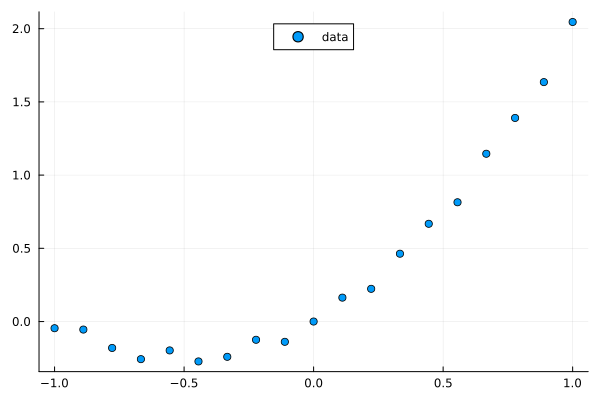

In [17]:
n = 18
t = range(-1,1,length=n+1)
y = @. t^2 + t + 0.05*sin(20*t)

scatter(t,y,label="data",leg=:top)

--- 

The points are unremarkable but the interpolant is quite unusual.

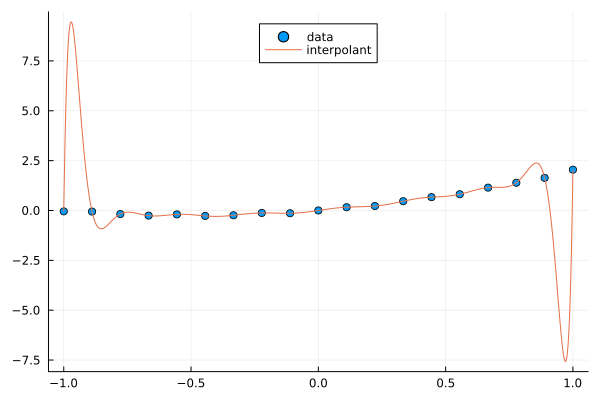

In [18]:
p = Polynomials.fit(t,y,n)
x = range(-1,1,length=1000)
plot!(x,p.(x),label="interpolant")

. . .

::: {.callout-warning icon=false}
## Fact: 
Interpolation by a polynomial at equally spaced nodes is ill-conditioned as the degree of the polynomial grows.
:::

## Piecewise polynomials

To keep polynomial degrees low while interpolating large data sets, we use **piecewise polynomials** as interpolants -- that is $p$ is a polynomial on each subinterval $[t_{k-1},t_k]$ for $k = 1, \cdots, n$.

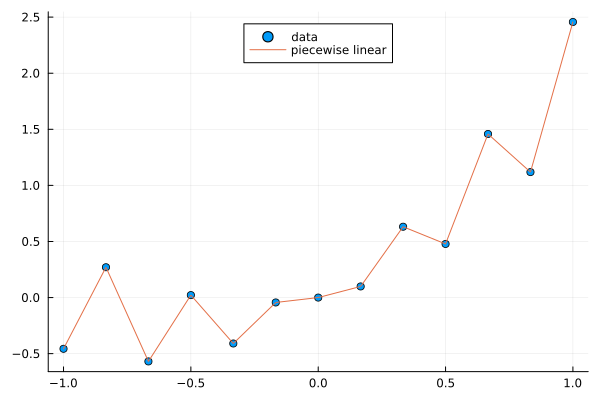

In [19]:
n = 12
t = range(-1,1,length=n+1)
y = @. t^2 + t + 0.5*sin(20*t)

scatter(t,y,label="data",leg=:top)

p = FNC.plinterp(t,y)
plot!(p,-1,1,label="piecewise linear")

In [20]:
# | echo: false

using Pkg; Pkg.add("Dierckx")
using Dierckx

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


---

We can even choose a higher degree polynomial for a smoother interpolant.

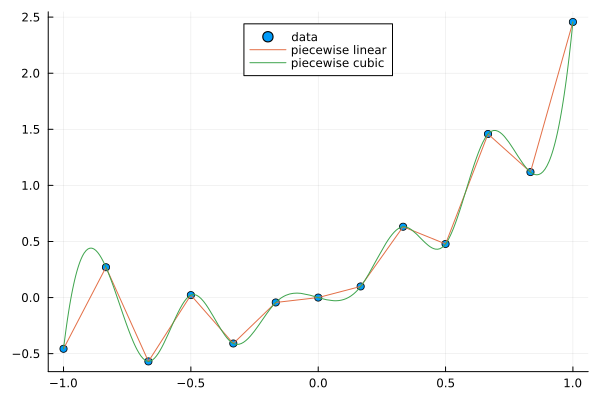

In [21]:
p = Spline1D(t,y)
plot!(x->p(x),-1,1,label="piecewise cubic")

## Conditioning of interpolation

We consider the nodes to be fixed and let $a = t_0, b = t_n$, so the data for the interpolant problem consists of the vector of $y$ values, $\mathbf{y}$, and the result is a function on $[a,b]$.

. . .

Suppose $\mathcal{I}$ is a method for producing the interpolant from a data vector -- that is $\mathcal{I}(\mathbf{y}) = p$, where $p(t_k) = y_k$ for all $k$.

. . .

We consider methods that are *linear*, which in particular, satisfy $$\mathcal{I}(\mathbf{y}) = \mathcal{I}\left(\sum_{k=0}^n y_k \mathbf{e}_k\right) = \sum_{k=0}^n y_k \mathcal{I}(\mathbf{e}_k).$$

. . .

::: {.callout-note icon=false}
## Definition: Cardinal function
A **cardinal function** $\phi_k$ for a node set $t_0, \cdots, t_n$ is the function that interpolates the value $(t_k,1)$ and $(t_j,0)$ for all $j \not= k$
:::

. . .

For any set of $n+1$ nodes, there are $n+1$ cardinal functions $\phi_0, \cdots, \phi_n$ which each single out a different interpolation node, and we then have $$\mathcal{I}(\mathbf{y}) = \sum_{k=0}^n y_k \phi_k.$$

---

We'll now measure the conditioning of the interpolation problem with respect to the function $\infty$-norm defined as $$\|f\|_\infty = \max_{x \in [a,b]} |f(x)|.$$

::: {.callout-warning icon=false}
## Theorem: Conditioning of interpolation
Suppose that $\mathcal{I}$ is a linear interpolation method on nodes $t_0, \cdots, t_n$.  Then with respect to $\|\cdot\|_\infty$, the absolute condition number of $\mathcal{I}$ satisfies $$\max_{0\le k \le n} \|\phi_k\|_\infty \le \kappa(\mathbf{y}) \le \sum_{k=0}^n \|\phi_k\|_\infty,$$ where the $\phi_k$ are cardinal interpolating functions.  
:::

---

<details><summary>Proof:</summary> 
Suppose the data is perturbed from $\mathbf{y}$ to $\mathbf{y} + \mathbf{d}$, then $$\frac{\|\mathcal{I}(\mathbf{y}+\mathbf{d}) - \mathcal{I}(\mathbf{y})\|_\infty}{\|\mathbf{d}\|_\infty} = \left\| \sum_{k=0}^n \frac{d_k}{\|\mathbf{d}\|_\infty}\phi_k\right\|_\infty.$$  The absolute condition number maximizes this quantity over all $\mathbf{d}$.  Suppose $j$ is such that $\|\phi_j\|_\infty$ is maximal.  Letting $\mathbf{d} = \mathbf{e}_j$, we have the lower bound for $\kappa(\mathbf{y})$.  The upper bound follows from the triangle inequality.
</details>

---

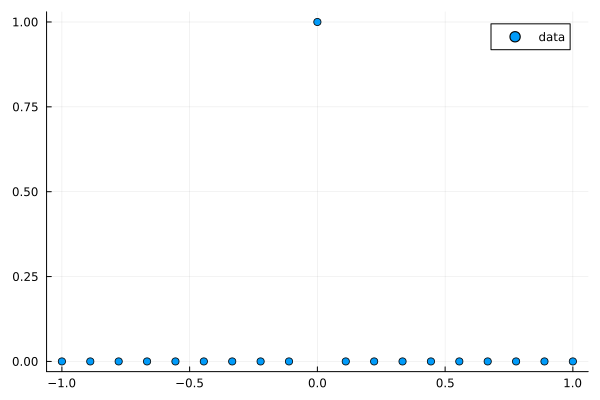

In [22]:
n = 18
t = range(-1,1,length=n+1)
y = [zeros(9);1;zeros(n-9)]

scatter(t,y,label="data")

---

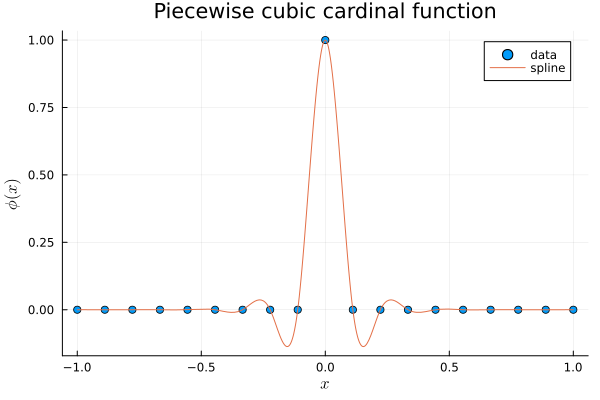

In [23]:
ϕ = Spline1D(t,y)
plot!(x->ϕ(x),-1,1,label="spline", xlabel=L"x",ylabel=L"\phi(x)",title="Piecewise cubic cardinal function")

. . .

The piecewise cubic cardinal function has $\|\phi\|_\infty \le 1$ which ensures a good condition number for any interpolation with these functions.  This is very different than the case for global polynomial interpolation!

---

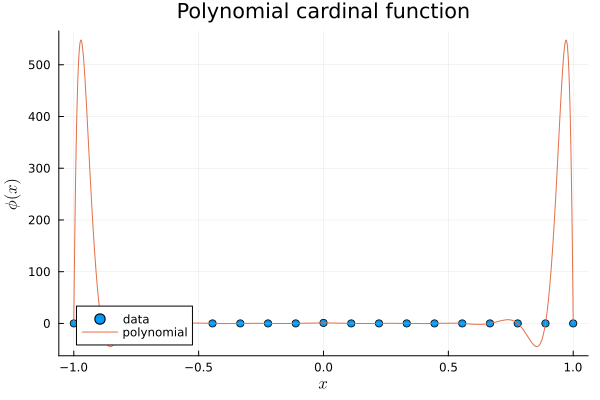

In [24]:
scatter(t,y,label="data")

ϕ = Polynomials.fit(t,y,n)
plot!(x->ϕ(x),-1,1,label="polynomial",xlabel=L"x",ylabel=L"\phi(x)",title="Polynomial cardinal function")

The condition number for global polynomial interpolation here is at least 500.

# Piecewise linear interpolation

Here, the data points are joined pair-wise by line segments.

::: {.callout-note icon=false}
## Definition: Piecewise linear interpolant
Given nodes $t_0 < t_1 < \cdots < t_n$, the **piecewise linear** interpolant $p(x)$ is given by $$p(x) = y_k + \frac{y_{k+1} - y_k}{t_{k+1}-t_k}(x - t_k) \quad\quad \text{ for } x \in [t_k, t_{k+1}].$$
:::

On each interval $[t_k,t_{k+1}]$, $p(x)$ is a linear function passing through $(t_k,y_k)$ and $(t_{k+1},y_{k+1})$.

## Hat functions

The interpolant is chosen from among linear combinations of a preselected finite set of functions known as **hat functions**; for $k = 0, \cdots, n$, 
$$H_k(x) = 
\begin{cases} 
\frac{x - t_{k-1}}{t_k - t_{k-1}} & \text{if } x \in [t_{k-1},t_k], \\ 
\frac{t_{k+1}-x}{t_{k+1}-t_k} & \text{if } x \in [t_k,t_{k+1}], \\ 
0 &\text{otherwise}.
\end{cases}$$

. . .

The hat functions form a **basis** for the set of functions that are continuous and piecewise linear relative to the node points $\mathbf{t}$.

---

In [26]:
"""
    hatfun(t,k)

Create a piecewise linear hat function, where `t` is a vector of n+1
interpolation nodes and `k` is an integer in 0:n giving the index of
the node where the hat function equals one.
"""
function hatfun(t,k)
    n = length(t)-1
    return function(x)
        if k > 0 && t[k] ≤ x ≤ t[k+1]
            return (x-t[k])/(t[k+1]-t[k])
        elseif k < n && t[k+1] ≤ x ≤ t[k+2]
            return (t[k+2] - x)/(t[k+2]-t[k+1])
        else
            return 0
        end
    end
end


hatfun

In [27]:
t = [0, 0.55, 0.7, 1]

4-element Vector{Float64}:
 0.0
 0.55
 0.7
 1.0

---

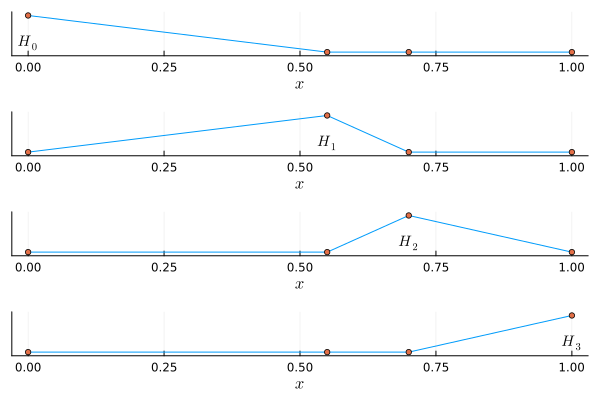

In [36]:
plt = plot(layout=(4,1),legend=:top,xlabel=L"x",ylims=[-0.1,1.1],ytick=[])
for k in 0:3
    Hk = hatfun(t,k)
    plot!(Hk,0,1,subplot=k+1,legend=false)
    scatter!(t,Hk.(t),m=3,subplot=k+1)
    annotate!(t[k+1],0.25,text(latexstring("H_$k"),10),subplot=k+1)
end
plt

## Cardinality conditions

Notice that hat functions are the cardinal functions for piecewise linear interpolation.  We can then say $$p(x) = \sum_{k=0}^n y_k H_k(x).$$

In [37]:
"""
    plinterp(t,y)

Construct a piecewise linear interpolating function for data values in `y` 
given at nodes in `t`.
"""
function plinterp(t,y)
    n = length(t)-1
    H = [ hatfun(t,k) for k in 0:n ]
    return x -> sum( y[k+1]*H[k+1](x) for k in 0:n )
end

plinterp

---

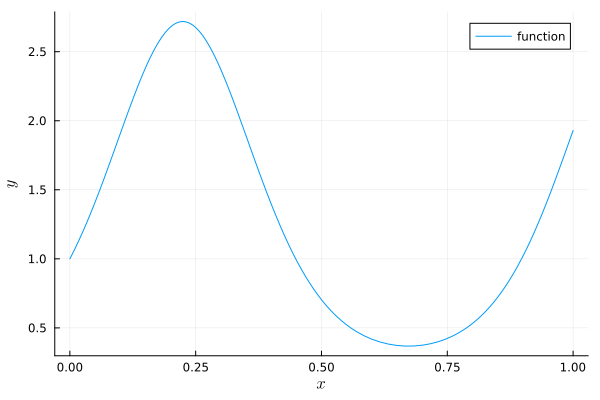

In [38]:
f = x -> exp(sin(7*x))

plot(f,0,1,label="function",xlabel=L"x",ylabel=L"y")

In [39]:
t = [0,0.075,0.25,0.55,0.7,1]   # nodes
y = f.(t)                       # function values 

6-element Vector{Float64}:
 1.0
 1.6507223907458943
 2.675097817245369
 0.5217195285817878
 0.37439173399608494
 1.9289708044108762

---

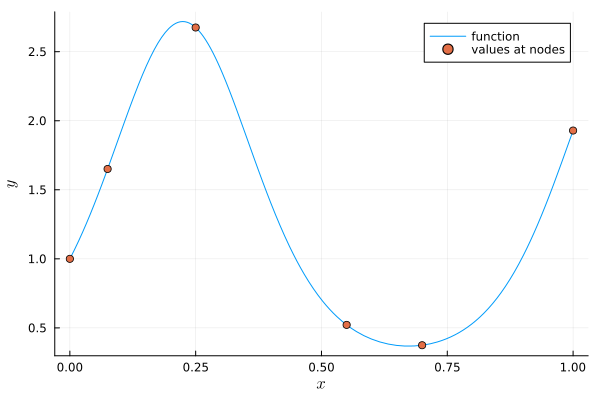

In [40]:
scatter!(t,y,label="values at nodes")

---

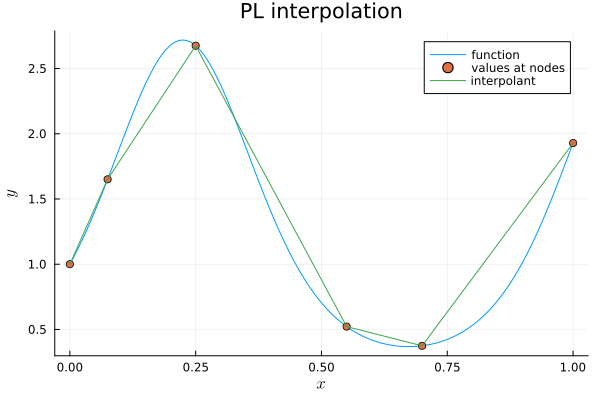

In [41]:
p = plinterp(t,y)
plot!(p,0,1,label="interpolant",title="PL interpolation")

## Conditioning and convergence

The previous condition number bounds give that the condition number for PL interpolation satisfies $1 \le \kappa \le n+1$.  However, an even stronger results is: 

::: {.callout-warning icon=false}
## Theorem: Conditioning of PL interpolation
The absolute condition number of piecewise linear interpolation in the infinity norm equals 1.  More specifically, if $\mathcal{I}$ is the piecewise linear interpolation operator, then $$\|\mathcal{I}(\mathbf{y}+\mathbf{z}) - \mathcal{I}(\mathbf{y})\|_\infty = \|\mathbf{z}\|_\infty.$$
:::

. . .

This result follows from linearity of $\mathcal{I}$ and the triangle inequality.

. . .

We also ask how close the PL interpolant $p(x)$ is to function $f$ that generated $\mathbf{y}$.

::: {.callout-warning icon=false}
## Theorem: Convergence of PL interpolation
Suppose that $f(x)$ has a continuous second derivative in $[a,b]$ ($f \in C^2[a,b]$).  Let $p_n(x)$ be the piecewise linear interpolant of $(t_i,f(t_i))$ for $i = 0, \cdots, n$, where $t_i = a + ih$ and $h = (b-a)/n$.  Then $$\|f - p_n\|_\infty = \max_{x\in[a,b]}|f(x) - p_n(x)| \le M h^2,$$ where $M = \|f''\|_\infty$.
:::

---

::: {.callout-note icon=false}
## Definition: Algebraic convergence
If an approximation has error that is $O(h^m)$ as $h \rightarrow 0$ for an integer $m$ and a discretization size parameter $h$, then we say the approximation has **algebraic convergence**.  if the error is not also $O(h^{m+1})$, then $m$ is the **order of accuracy**.
:::

. . .

PL interpolation is second-order accurate.  

In [44]:
# | echo: false

using Pkg; Pkg.add("PrettyTables")
using PrettyTables

   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [08abe8d2] + PrettyTables v2.4.0
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [50]:
x = range(0,1,length=10001)
n = @. round(Int,10^(1:0.25:3.5))
maxerr = zeros(0)
for n in n
    t = (0:n)/n      # interpolation nodes
    p = plinterp(t,f.(t))
    err = @. f(x) - p(x)
    push!(maxerr,norm(err,Inf))
end

data = (n=n[1:4:end],err=maxerr[1:4:end])
pretty_table(data)

┌───────┬────────────┐
│     n │        err │
│ Int64 │    Float64 │
├───────┼────────────┤
│    10 │   0.150471 │
│   100 │ 0.00166421 │
│  1000 │ 1.66494e-5 │
└───────┴────────────┘


---

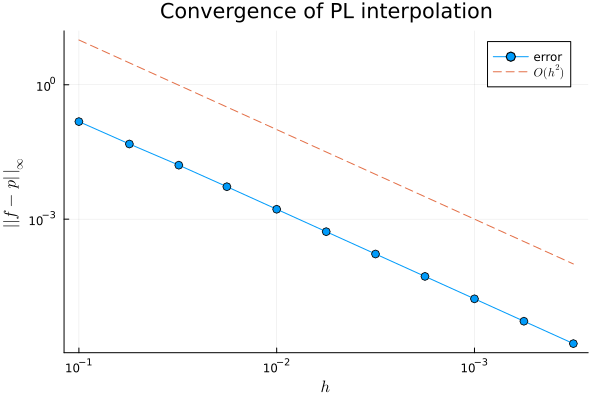

In [51]:
h = @. 1/n
order2 = @. 10*(h/h[1])^2

plot(h,maxerr,m=:o,label="error")
plot!(h,order2,l=:dash,label=L"O(h^2)",xflip=true,xaxis=(:log10,L"h"),yaxis=(:log10,L"|| f-p\, ||_\infty"),title="Convergence of PL interpolation")

# Cubic splines

Piecewise cubic interpolation provides a smoother interpolant than PL interpolation, and has continuous derivatives.

::: {.callout-note icon=false}
## Definition: Cubic spline
A **cubic spline** is a piecewise cubic function that has two continuous derivatives everywhere.
:::

. . .

The spline $(x)$ is defined on the interval $[t_{k-1},t_k]$ by cubic polynomial $$S_k(x) = a_k + b_k(x - t_{k-1}) + c_k(x - t_{k-1})^2 + d_k(x - t_{k-1})^3, \quad\quad k=1,\cdots,n,$$ where $a_k, b_k, c_k, d_k$ are values to be determined.  Overall there are $4n$ such undetermined coefficients.

## Smoothness conditions

The following constraints guarantee that $S$ has at least two continuous derivative everywhere.

---

1. $S_k(t_{k-1}) = y_{k-1}$ and $S_k(t_k) = y_k$ for every $k = 1, \cdots, n$.

. . .

This condition can be rewritten as $a_k = y_{k-1}$ and $a_k + b_k h_k + c_k h_k^2 + d_k h_k^3 = y_k$ for $k = 1, \cdots, n$.  These linear constraints can be written as 
$$\begin{bmatrix} 
\mathbf{I} & \mathbf{0} & \mathbf{0} & \mathbf{0} 
\end{bmatrix} 
\begin{bmatrix} 
\mathbf{a} \\ 
\mathbf{b} \\ 
\mathbf{c} \\ 
\mathbf{d} 
\end{bmatrix} = 
\begin{bmatrix} 
y_0 \\ 
\vdots \\ 
y_{n-1} 
\end{bmatrix},$$
and 
$$\begin{bmatrix} 
\mathbf{I} & \mathbf{H} & \mathbf{H}^2 & \mathbf{H}^3 
\end{bmatrix} 
\begin{bmatrix} 
\mathbf{a} \\ 
\mathbf{b} \\ 
\mathbf{c} \\ 
\mathbf{d} 
\end{bmatrix} = 
\begin{bmatrix} 
y_1 \\ 
\vdots \\ 
y_{n} 
\end{bmatrix}$$
where $\mathbf{H}$ is a diagonal matrix with $h_1, \cdots, h_n$ on the diagonal.

---

2. Continuity of $S'(x)$ at interior nodes.

. . .

This can be written as $b_k + 2 c_k h_k + 3 d_k h_k^2 = b_{k+1}$ for $k = 1,, \cdots, n-1$.  

This can be rewritten as 
$$\mathbf{E} 
\begin{bmatrix} 
\mathbf{0} & \mathbf{J} & 2\mathbf{H} & 3\mathbf{H}^2 
\end{bmatrix}
\begin{bmatrix} 
\mathbf{a} \\ 
\mathbf{b} \\ 
\mathbf{c} \\ 
\mathbf{d} \end{bmatrix} = \mathbf{0},$$ where $\mathbf{J}$ has ones on the diagonal and $-1$s on the first diagonal, and zeros elsewhere, and $\mathbf{E}$ is the $(n-1) \times n$ matrix obtained by deleting the last row from the identity matrix.

---

3. Continuity of $S''(x)$ at interior nodes.

. . .

This can be written as $2c_k + 6 d_k h_k = 2 c_{k+1}$ for $k = 1, \cdots, n-1$.  

This can be rewritten as 
$$\mathbf{E} \begin{bmatrix} 
\mathbf{0} & \mathbf{0} & \mathbf{J} & 3\mathbf{H} 
\end{bmatrix}
\begin{bmatrix} 
\mathbf{a} \\ 
\mathbf{b} \\ 
\mathbf{c} \\ 
\mathbf{d} 
\end{bmatrix} = \mathbf{0}.$$

## End conditions

So far there are $4n-2$ conditions on the $4n$ unknowns.  To get a well-defined problem, we add two more constraints.  There are two typical approaches:

* **Natural spline**: $S_1''(t_0) = S''_n(t_n) = 0$
* **Not-a-knot spline**: $S_1'''(t_1) = S_2'''(t_1)$, $S_{n-1}'''(t_{n-1}) = S_n'''(t_{n-1})$

. . .

We consider the *not-a-knot* spline as they give better pointwise accuracy.

. . .

Algebraically, these conditions are $d_1 = d_2$, $d_{n-1} = d_n$.  We append these to the systems we built above.  

. . .

Note that there is no closed form expression for a *cardinal* basis for the cubic spline, so the process of computing it requires solving the constructed linear system.

---

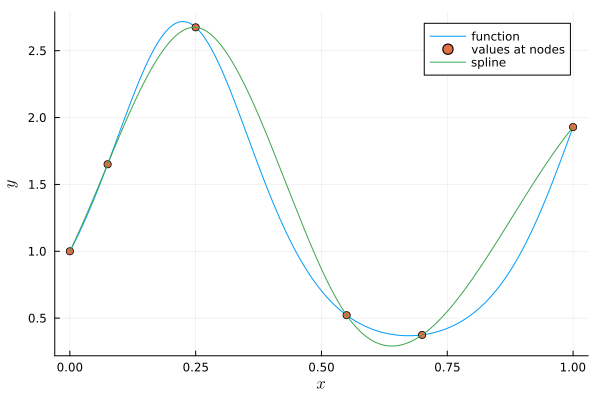

In [55]:
plot(f,0,1,label="function",xlabel=L"x",ylabel=L"y")

t = [0, 0.075, 0.25, 0.55, 0.7, 1]
y = f.(t)

scatter!(t,y,label="values at nodes")

S = FNC.spinterp(t,y)

plot!(S,0,1,label="spline")

---

In [60]:
x = (0:10000)/1e4               # sample the differences at many points
n = @. round(Int,2^(3:0.5:7))   # numbers of nodes 
errs = zeros(0)
for n in n
    t = (0:n)/n
    S = FNC.spinterp(t,f.(t))
    dif = @. f(x) - S(x)
    push!(errs,norm(dif,Inf))
end

pretty_table((n=n,error=errs))

┌───────┬─────────────┐
│     n │       error │
│ Int64 │     Float64 │
├───────┼─────────────┤
│     8 │   0.0305634 │
│    11 │   0.0207562 │
│    16 │  0.00590761 │
│    23 │  0.00134587 │
│    32 │ 0.000367049 │
│    45 │  9.17785e-5 │
│    64 │  2.15306e-5 │
│    91 │  5.04292e-6 │
│   128 │  1.24012e-6 │
└───────┴─────────────┘


---

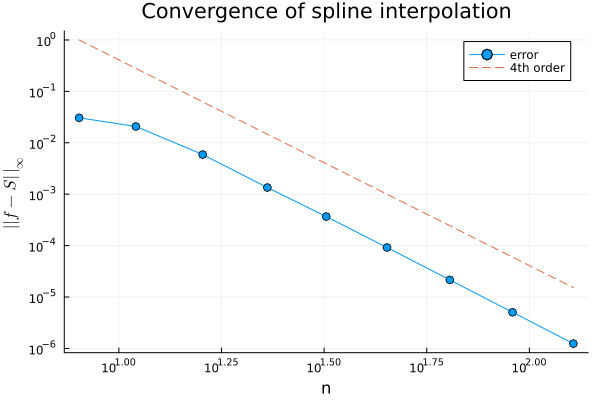

In [64]:
order4 = @. (n/n[1])^(-4)

plot(n,[errs order4],m=[:o :none],l=[:solid :dash],label=["error" "4th order"], xaxis=(:log10, "n"), yaxis=(:log10,L"|| f-S\,||_\infty"),title="Convergence of spline interpolation")

. . .

::: {.callout-warning icon=false}
## Theorem: 
Suppose that $f(x)$ has four continuous derivatives in $[a,b]$.  Let $S_n(x)$ be the not-a-knot cubic spline interpolant of $(t_i,f(t_i))$ for $i = 0, \cdots, n$, where $t_i = a + ih$ and $h = (b-a)/n$.  Then for all sufficiently small $h$, there is a constant $C > 0$ such that $$\|f - S_n\|_\infty \le C h^4.$$
:::

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->